# Twin similarity

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from itertools import combinations

In [16]:
def calculate_twin_similarity(twin_df, clone_id_col='clone_id', selected_columns=None):
    """
    Calculate euclidean distances between twin pairs within each clone group.
    Assumes exactly 2 objects per clone.
    
    Parameters:
    -----------
    twin_df : pandas.DataFrame
        DataFrame containing twin/clone data
    clone_id_col : str, default 'clone_id'
        Column name that contains the clone/group identifiers
    selected_columns : list, optional
        List of column names to use for distance calculation.
        If None, uses all numeric columns except the clone_id_col
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: clone_id, twin_1_idx, twin_2_idx, euclidean_distance
    """
    
    # If no columns specified, use all numeric columns except clone_id
    if selected_columns is None:
        selected_columns = [column for column in twin_df.columns if "mRNA" in column]
    if clone_id_col in selected_columns:
        selected_columns.remove(clone_id_col)
    
    # Validate that selected columns exist
    missing_cols = set(selected_columns) - set(twin_df.columns)
    if missing_cols:
        raise ValueError(f"Columns not found in DataFrame: {missing_cols}")
    
    results = []
    
    # Group by clone_id and process each group
    for clone_id, group in twin_df.groupby(clone_id_col):
        # Verify we have exactly 2 twins per clone
        if len(group) != 2:
            print(f"Warning: Clone {clone_id} has {len(group)} objects, expected 2. Skipping.")
            continue
        
        # Get the twin data
        twin_data = group[selected_columns].values
        twin_indices = group.index.tolist()
        
        # Calculate euclidean distance between the two twins
        distance = euclidean(twin_data[0], twin_data[1])
        
        # Store the result
        results.append({
            'clone_id': clone_id,
            'twin_1_idx': twin_indices[0],
            'twin_2_idx': twin_indices[1], 
            'euclidean_distance': distance
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    return result_df

In [40]:
simulation_no_noise = pd.read_csv("/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_to_B/df_rows_0_1_05082025_160041_ncells_6000_A_to_B_rep_0.csv")
simulation_1pct_noise = pd.read_csv("/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/noisy_division/df_rows_0_0_16082025_143349_ncells_6000_A_to_B_rep_1_49aa7524.csv")
simulation_50pct_noise = pd.read_csv("/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/noisy_division/df_rows_0_0_15082025_221855_ncells_6000_A_to_B_50_percent_rep_0_2b023cdf.csv")



In [54]:
filter_species = "protein"
columns = [column for column in simulation_no_noise.columns if filter_species in column]
t = 0
time_0_simulation_no_noise = simulation_no_noise[simulation_no_noise['time_step'] == t]
time_0_simulation_no_noise_random = time_0_simulation_no_noise.copy()
time_0_simulation_no_noise_random['clone_id'] = np.random.permutation(time_0_simulation_no_noise_random['clone_id'])
distance_df_no_noise = calculate_twin_similarity(time_0_simulation_no_noise, selected_columns = columns)
distance_df_no_noise_random = calculate_twin_similarity(time_0_simulation_no_noise_random, selected_columns = columns)

time_0_simulation_1pct_noise = simulation_1pct_noise[simulation_1pct_noise['time_step'] == t]
time_0_simulation_1pct_noise_random = time_0_simulation_1pct_noise.copy()
time_0_simulation_1pct_noise_random['clone_id'] = np.random.permutation(time_0_simulation_1pct_noise_random['clone_id'])
distance_df_1pct_noise = calculate_twin_similarity(time_0_simulation_1pct_noise, selected_columns = columns)
distance_df_1pct_noise_random = calculate_twin_similarity(time_0_simulation_1pct_noise_random, selected_columns = columns)

time_0_simulation_50pct_noise = simulation_50pct_noise[simulation_50pct_noise['time_step'] == t]
time_0_simulation_50pct_noise_random = time_0_simulation_50pct_noise.copy()
time_0_simulation_50pct_noise_random['clone_id'] = np.random.permutation(time_0_simulation_50pct_noise_random['clone_id'])
distance_df_50pct_noise = calculate_twin_similarity(time_0_simulation_50pct_noise, selected_columns = columns)
distance_df_50pct_noise_random = calculate_twin_similarity(time_0_simulation_50pct_noise_random, selected_columns = columns)


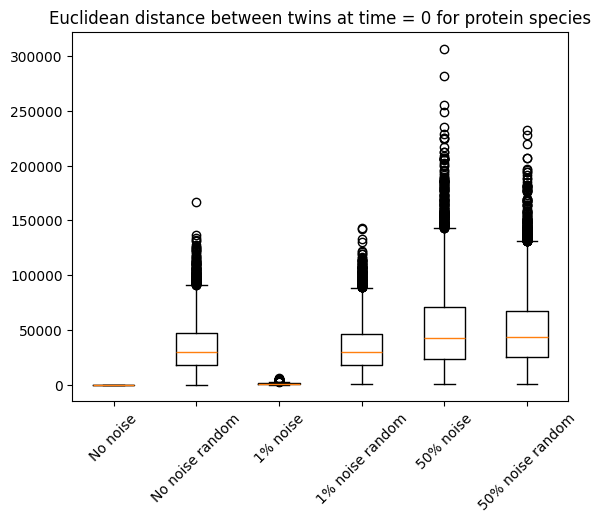

In [55]:
plt.boxplot([distance_df_no_noise['euclidean_distance'], distance_df_no_noise_random['euclidean_distance'], distance_df_1pct_noise['euclidean_distance'], distance_df_1pct_noise_random['euclidean_distance'], distance_df_50pct_noise['euclidean_distance'], distance_df_50pct_noise_random['euclidean_distance']])
plt.title(f"Euclidean distance between twins at time = {t} for {filter_species} species")
plt.xticks([1,2,3, 4, 5, 6], ["No noise", "No noise random", "1% noise", "1% noise random", "50% noise", "50% noise random"], rotation = 45)
plt.show()